# Cross-Version Benchmark Leaderboards

This notebook builds leaderboards from benchmark outputs in `benchmarking/benchmarks/*/results/baseline` and `v10+`.

**v13 is excluded.** Captioning failures during indexing (empty-caption DLQ force-inserts and abandoned items) left collections incomplete or degraded and inflated retrieval scores. The run remains under `results/v13/` for the record; v14 is the first comparable Milvus dual-index / CLIP DFN run after those failures were addressed.

When present, `baseline` is the CLIP-only ablation (no caption generation, keyword search, or hybrid search).

It includes:
- Primary leaderboard (`MRR`, `Success@25`)
- Primary + Diversity leaderboard (adds `Diversity@25`)

`Success@25` is computed from the `hit` column mean.


A separate **Primary leaderboard (with ablation studies)** section includes `ablation_*` runs alongside baseline and `v10+`.


In [1]:
import sys
from pathlib import Path
from IPython.display import display

# Repo root from benchmarking/benchmarks/<BENCHMARK>/results
_repo_root = Path.cwd().parents[3]
sys.path.insert(0, str(_repo_root))

base_path = (_repo_root / "benchmarking" / "benchmarks").resolve()

from benchmarking.helpers.plot import (
    render_single_benchmark_leaderboard,
    DEFAULT_PRIMARY_WEIGHTS,
    DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS,
)

In [2]:
# Configuration
# This notebook ranks only the benchmark folder it lives in.
# Expected cwd when running this notebook: benchmarking/benchmarks/<BENCHMARK>/results
current_benchmark = Path.cwd().parents[0].name if Path.cwd().name == "results" else Path.cwd().name
min_version = 10

# Default metric weights are equal, but can be customized.
primary_metric_weights = dict(DEFAULT_PRIMARY_WEIGHTS)
primary_plus_diversity_metric_weights = dict(DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS)

print("Base path:", base_path)
print("Benchmark selected:", current_benchmark)
print("Primary weights:", primary_metric_weights)
print("Primary + Diversity weights:", primary_plus_diversity_metric_weights)

Base path: /home/runner/work/sage-nrp-image-search/sage-nrp-image-search/benchmarking/benchmarks
Benchmark selected: Commonobjectsbench
Primary weights: {'MRR': 0.5, 'Success@25': 0.5}
Primary + Diversity weights: {'MRR': 0.3333333333333333, 'Success@25': 0.3333333333333333, 'Diversity@25': 0.3333333333333333}


## Primary Leaderboard

Ranking uses weighted composite of:
- `MRR`
- `Success@25`


Commonobjectsbench (Primary):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Commonobjectsbench,v16,291,0.259268,0.573883,0.025155,0.320486,0.402067,0.360910,0.416576,1
1,Commonobjectsbench,v11,291,0.220065,0.594502,0.026667,0.304077,0.429857,0.371605,0.407283,2
2,Commonobjectsbench,v12,291,0.165180,0.615120,0.026942,0.261192,0.419166,0.354889,0.390150,3
3,Commonobjectsbench,v10,291,0.178307,0.601375,0.026804,0.266344,0.403363,0.357059,0.389841,4
4,Commonobjectsbench,v14,291,0.247473,0.505155,0.021718,0.309695,0.332490,0.395564,0.376314,5
5,Commonobjectsbench,v15,291,0.228579,0.460481,0.020344,0.276778,0.320185,0.381582,0.344530,6
6,Commonobjectsbench,baseline,291,0.164983,0.494845,0.021856,0.164603,0.349353,0.254607,0.329914,7


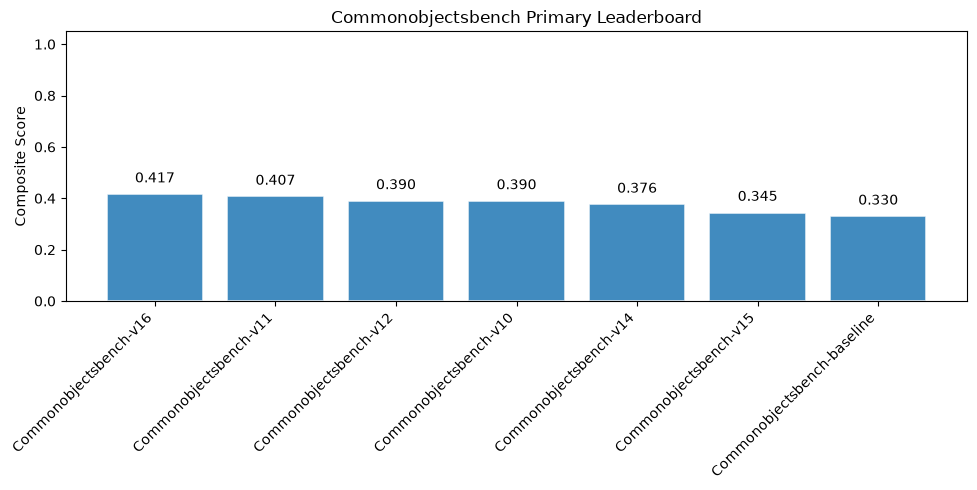

In [3]:
primary_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    mode="primary",
    metric_weights=primary_metric_weights,
    display_fn=display,
)

## Primary + Diversity Leaderboard

Adds `Diversity@25` to the weighted score.


Commonobjectsbench (Primary + Diversity):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Commonobjectsbench,v16,291,0.259268,0.573883,0.025155,0.320486,0.402067,0.360910,0.398021,1
1,Commonobjectsbench,v11,291,0.220065,0.594502,0.026667,0.304077,0.429857,0.371605,0.395390,2
2,Commonobjectsbench,v14,291,0.247473,0.505155,0.021718,0.309695,0.332490,0.395564,0.382730,3
3,Commonobjectsbench,v10,291,0.178307,0.601375,0.026804,0.266344,0.403363,0.357059,0.378914,4
4,Commonobjectsbench,v12,291,0.165180,0.615120,0.026942,0.261192,0.419166,0.354889,0.378396,5
5,Commonobjectsbench,v15,291,0.228579,0.460481,0.020344,0.276778,0.320185,0.381582,0.356881,6
6,Commonobjectsbench,baseline,291,0.164983,0.494845,0.021856,0.164603,0.349353,0.254607,0.304812,7


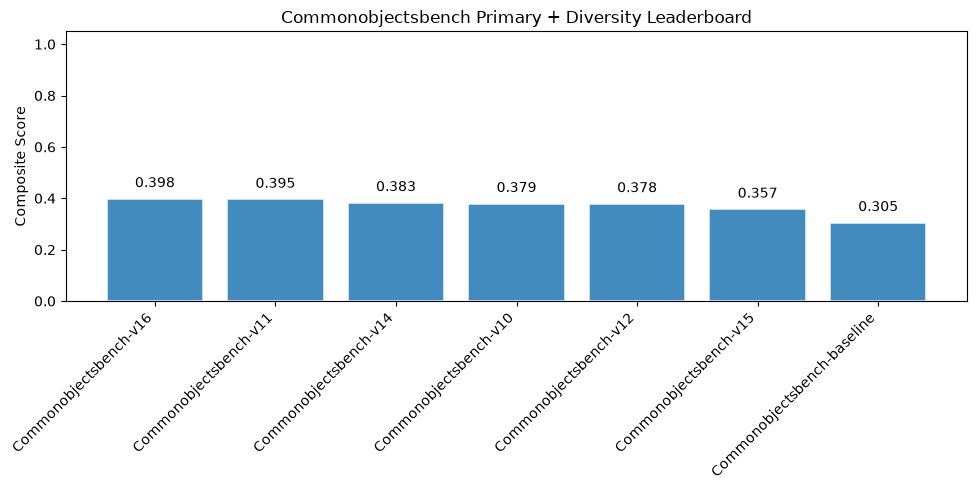

In [4]:
primary_plus_diversity_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    mode="primary_plus_diversity",
    metric_weights=primary_plus_diversity_metric_weights,
    display_fn=display,
)

## Primary Leaderboard (with Ablation Studies)

Same weighted composite as the primary leaderboard (`MRR`, `Success@25`), but also includes `ablation_*` result folders when present.



Commonobjectsbench (Primary (with Ablation Studies)):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Commonobjectsbench,ablation_img_only,291,0.265653,0.683849,0.030103,0.227345,0.460971,0.307436,0.474751,1
1,Commonobjectsbench,ablation_vec_only,291,0.200356,0.656357,0.029553,0.297161,0.454772,0.307918,0.428356,2
2,Commonobjectsbench,v16,291,0.259268,0.573883,0.025155,0.320486,0.402067,0.360910,0.416576,3
3,Commonobjectsbench,v11,291,0.220065,0.594502,0.026667,0.304077,0.429857,0.371605,0.407283,4
4,Commonobjectsbench,v12,291,0.165180,0.615120,0.026942,0.261192,0.419166,0.354889,0.390150,5
5,Commonobjectsbench,v10,291,0.178307,0.601375,0.026804,0.266344,0.403363,0.357059,0.389841,6
6,Commonobjectsbench,v14,291,0.247473,0.505155,0.021718,0.309695,0.332490,0.395564,0.376314,7
7,Commonobjectsbench,v15,291,0.228579,0.460481,0.020344,0.276778,0.320185,0.381582,0.344530,8
8,Commonobjectsbench,baseline,291,0.164983,0.494845,0.021856,0.164603,0.349353,0.254607,0.329914,9
9,Commonobjectsbench,ablation_cap_only,291,0.174924,0.474227,0.021718,0.237996,0.353904,0.492661,0.324575,10


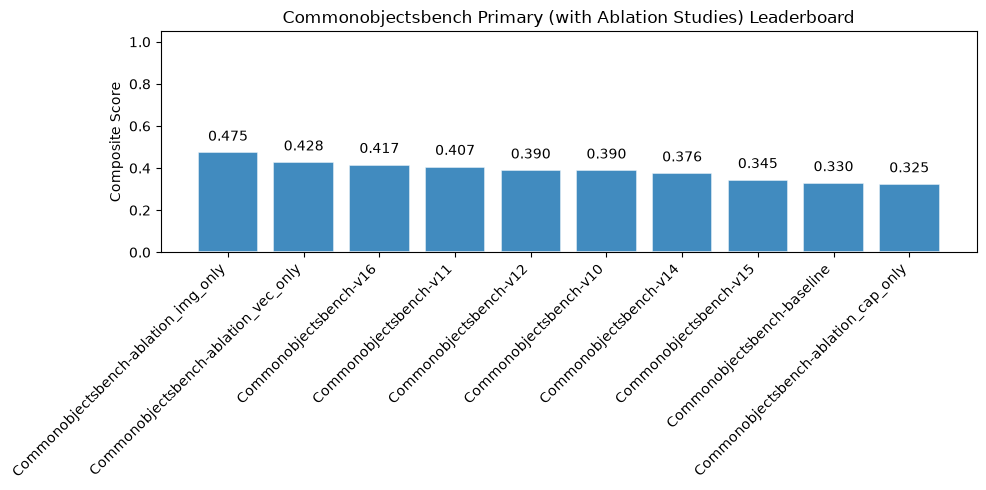

In [5]:
primary_ablation_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    include_ablations=True,
    mode="primary",
    metric_weights=primary_metric_weights,
    display_fn=display,
)